In [1]:
import torch
import numpy as np
import random
from models import *
import matplotlib.pyplot as plt
from diffusers import LMSDiscreteScheduler, DDIMScheduler, AutoencoderKL
from utils import *
import timeit
import h5py

from evaluation import *

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the autoencoder model which will be used to decode the latents into image space. 
vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="vae")
# To the GPU we go!
vae = vae.to(device)


# The noise scheduler
noise_scheduler = LMSDiscreteScheduler(
    beta_start=0.00085, beta_end=0.012, beta_schedule="scaled_linear", num_train_timesteps=1000
)

In [2]:
# Load dataset
f = h5py.File('TScells_chunked_256x256_3D_normtif_2col_timeidx_float32_413968.h5','r')

# Calcium signals images
images = f['tif_arr']
# Time point of data
labels_raw = f['y_time'][:]

q1 = 59
q2 = 19999

print("\n Range of unnormalized labels: ({},{})".format(np.min(labels_raw), np.max(labels_raw))) 
# Normalize the labels
labels = np.empty(labels_raw.shape)
labels[:,0] = labels_raw[:,0] / q1
labels[:,1] = labels_raw[:,1] / q2
print("\n Range of normalized labels: ({},{})".format(np.min(labels), np.max(labels)))


 Range of unnormalized labels: (0.0,19999.0)

 Range of normalized labels: (0.0,1.0)


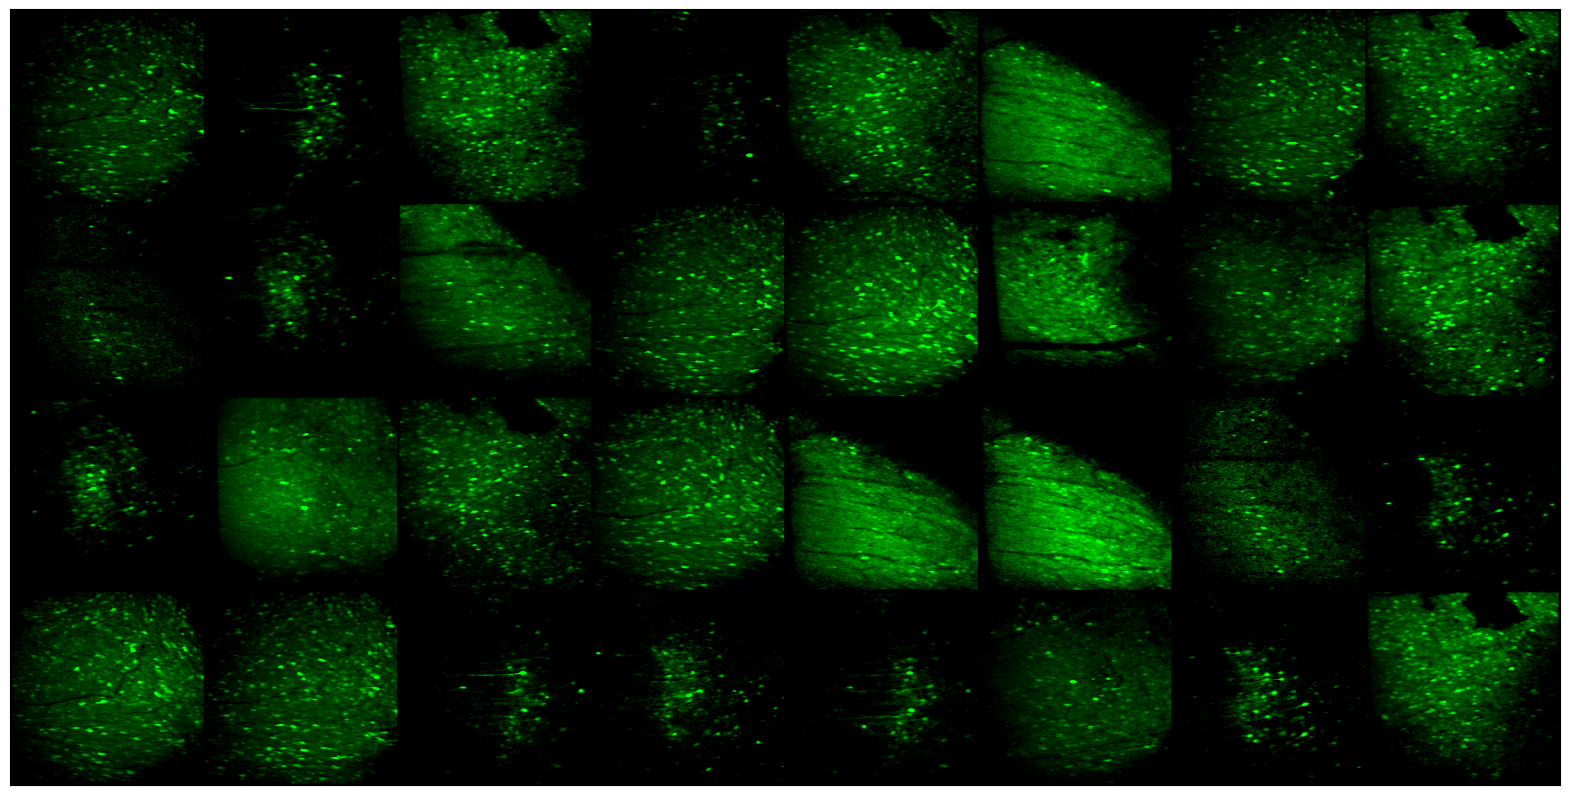

In [3]:
# Show some real images: x
batch_size = 32
trainset = IMGs_dataset(images, labels, normalize=True)
train_dataloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
dataloader_iter = iter(train_dataloader)
batch_train_images, batch_train_labels = next(dataloader_iter)
assert batch_size == batch_train_images.shape[0]
batch_train_images = batch_train_images.type(torch.float).to(device)
batch_train_labels = batch_train_labels.type(torch.float).to(device)
    
show_images(batch_train_images)

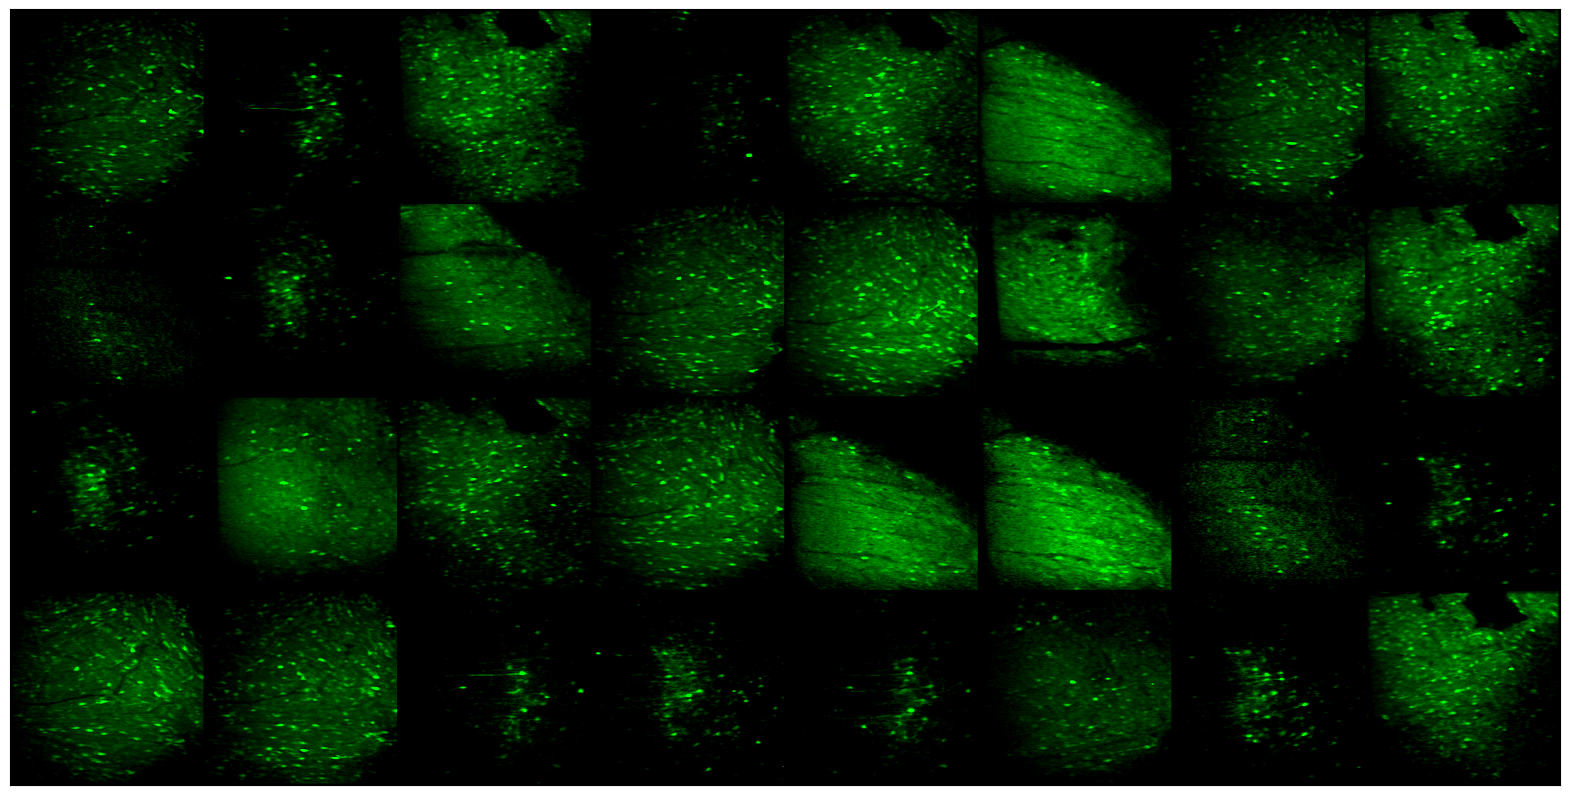

In [4]:
with torch.no_grad():
    latents = vae.encode(batch_train_images).latent_dist.sample()
latent_batch_train_images = latents * 0.18215  

vae_sample_recon = (1 / 0.18215) * latent_batch_train_images
with torch.no_grad():
    vae_sample_recon = vae.decode(vae_sample_recon).sample 
    
show_images(vae_sample_recon)    

In [5]:
# Load pre-trained model
niters = 50000
save_models_folder = 'output/saved_models'

Filename_LDM = save_models_folder + '/CcLDM_checkpoint_intrain/CcLDM_checkpoint_niters_{}.pth'.format(niters)
print("Loading pre-trained continuous conditional latent diffusion model >>>")
checkpoint = torch.load(Filename_LDM, map_location=device, weights_only=True)
netLDM = cont_cond_unet_diffusion_model().to(device)
netLDM = nn.DataParallel(netLDM)

# Adjust checkpoint keys if necessary
checkpoint_state_dict = checkpoint['netLDM_state_dict']
adjusted_state_dict = {}

for key, value in checkpoint_state_dict.items():
    # Replace naming inconsistencies
    new_key = key.replace("query", "to_q").replace("key", "to_k").replace("value", "to_v").replace("proj_attn", "to_out.0")
    adjusted_state_dict[new_key] = value

# Load the adjusted state dict
netLDM.load_state_dict(adjusted_state_dict, strict=True)

Loading pre-trained continuous conditional latent diffusion model >>>


<All keys matched successfully>

  0%|          | 0/999 [00:00<?, ?it/s]

  0%|          | 0/999 [00:00<?, ?it/s]

Wall-clock time: 85.12449765205383 seconds


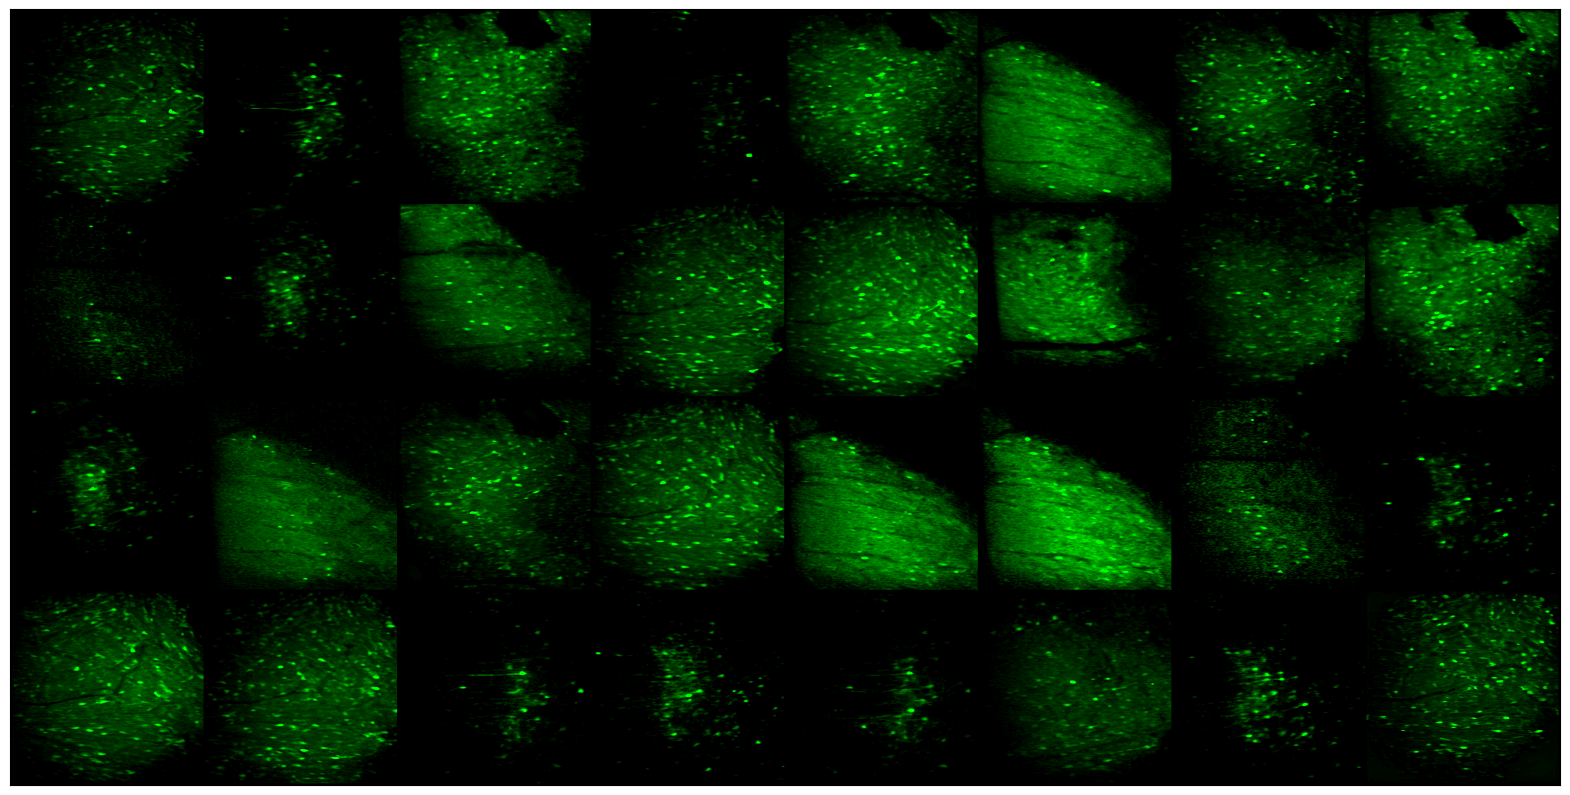

In [6]:
# DDIM Reconstruction
from ddim import *

import time
start = time.time()
inf_steps = 1000
ddim_latents = invert(latent_batch_train_images, num_inference_steps=inf_steps, labels=batch_train_labels,
                      noise_scheduler=noise_scheduler, netLDM=netLDM, device=device)
ddim_recon = sample(start_latents=ddim_latents[-1], num_inference_steps=inf_steps, labels=batch_train_labels, 
                    noise_scheduler=noise_scheduler, netLDM=netLDM, start_step=0, device=device)

# Decode reconstructed latents back to image space using VAE decoder: D(z_0)
ddim_recon = (1 / 0.18215) * ddim_recon[-1]
with torch.no_grad():
    ddim_recon = vae.decode(ddim_recon).sample 
end = time.time()
print("Wall-clock time:", end - start, "seconds")
show_images(ddim_recon)

tensor(-531.1045, device='cuda:0') tensor(590.8143, device='cuda:0')
Wall-clock time: 8.435691118240356 seconds


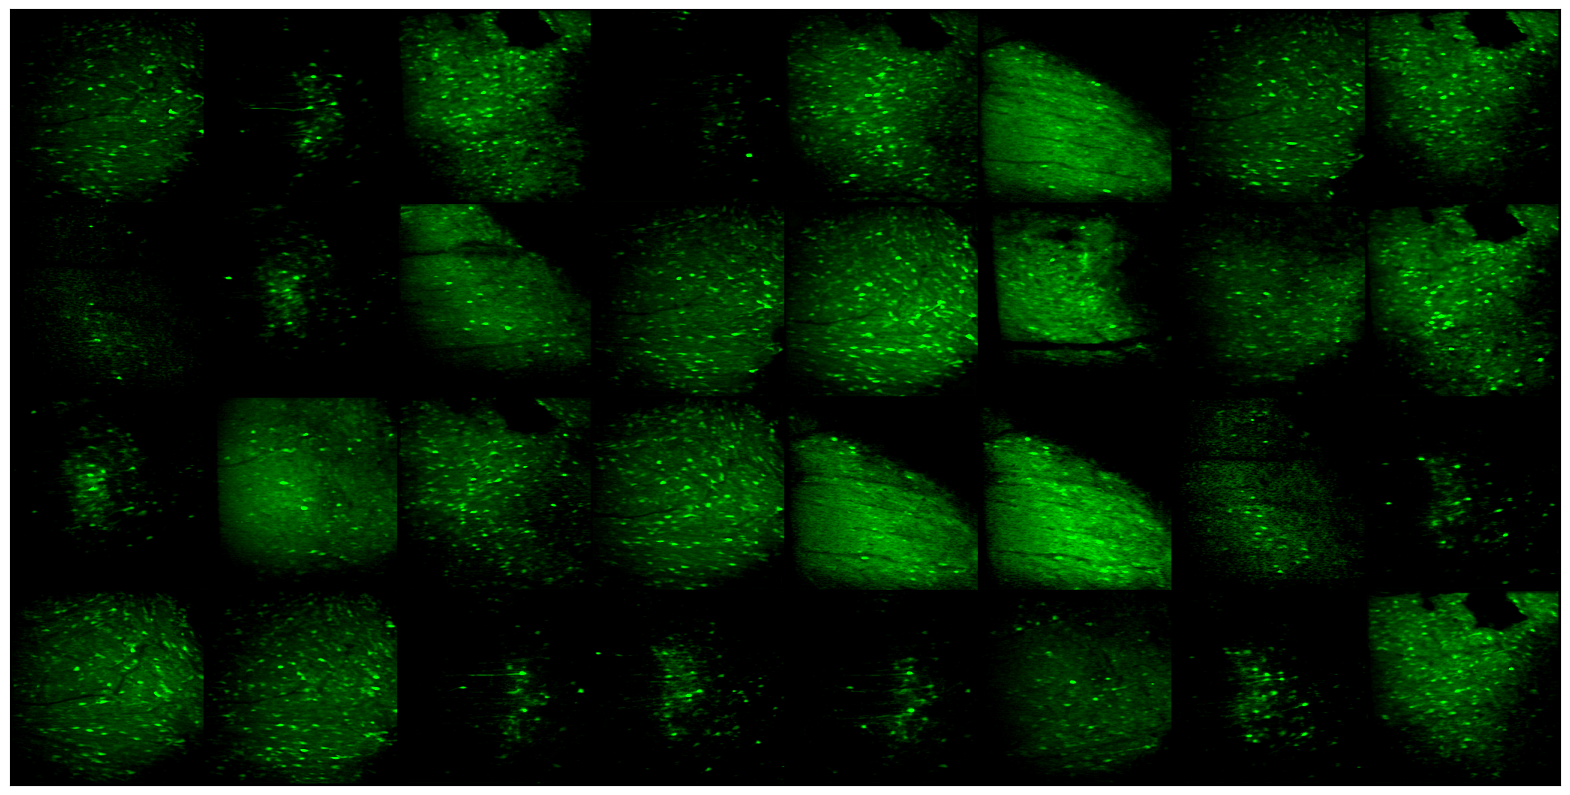

In [7]:
from Rex_RK4 import *

import time
start = time.time()

num_inference_steps = 8
noise_scheduler.set_timesteps(num_inference_steps, device=device)  # e.g., torch.linspace(0., T, steps+1) or log-sigma grid

t_grid = noise_scheduler.timesteps.to(torch.float32)

# Rex prefers time increasing (0 → 1), so flip them:
t_grid = torch.flip(t_grid,dims=[0])

schedule = DDIMPfODEAdapter(noise_scheduler, t_grid)
pf_ode = PFODE(model=netLDM, schedule=schedule, pred_type="eps", cond=batch_train_labels)

z_T   = rex_encode(pf_ode, t_grid, latent_batch_train_images)        # data -> latent (ODE integrate 0→T)
print(torch.min(z_T),torch.max(z_T))
z_hat = rex_decode(pf_ode, t_grid, z_T)       # latent -> data (exact inverse T→0)

#show_images(z_T)
end = time.time()
print("Wall-clock time:", end - start, "seconds")

z_hat = (1 / 0.18215) * z_hat
with torch.no_grad():
    x_hat = vae.decode(z_hat).sample 
show_images(x_hat)

In [8]:
psnr_ddim = []
ssim_ddim = []

psnr_rex = []
ssim_rex = []

for i in range(batch_size):
    psnr_ddim.append(PSNR(normalize(batch_train_images[i]),normalize(ddim_recon[i])))
    ssim_ddim.append(structural_similarity_index_measure(ddim_recon[i:i+1], batch_train_images[i:i+1]).item())    

    psnr_rex.append(PSNR(normalize(batch_train_images[i]),normalize(x_hat[i])))
    ssim_rex.append(structural_similarity_index_measure(x_hat[i:i+1], batch_train_images[i:i+1]).item())    

print(f"PSNR with DDIM: Mean ± Std: {np.mean(psnr_ddim):.2f} ± {np.std(psnr_ddim):.2f}")
print(f"SSIM with DDIM: Mean ± Std: {np.mean(ssim_ddim):.2f} ± {np.std(ssim_ddim):.2f}")

print(f"PSNR with Rex-RK4: Mean ± Std: {np.mean(psnr_rex):.2f} ± {np.std(psnr_rex):.2f}")
print(f"SSIM with Rex-RK4: Mean ± Std: {np.mean(ssim_rex):.2f} ± {np.std(ssim_rex):.2f}")    

PSNR with DDIM: Mean ± Std: 36.61 ± 4.12
SSIM with DDIM: Mean ± Std: 0.86 ± 0.10
PSNR with Rex-RK4: Mean ± Std: 37.20 ± 3.62
SSIM with Rex-RK4: Mean ± Std: 0.88 ± 0.07
